<a href="https://colab.research.google.com/github/NikitaIvagin/ml-portfolio/blob/main/nlp/author_identification/Author_identification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget https://storage.yandexcloud.net/academy.ai/russian_literature.zip
!unzip -qo "russian_literature" -d ./dataset

--2025-12-23 17:28:23--  https://storage.yandexcloud.net/academy.ai/russian_literature.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21547079 (21M) [application/x-zip-compressed]
Saving to: ‘russian_literature.zip’

russian_literature. 100%[===================>]  20.55M  7.64MB/s    in 2.7s    

2025-12-23 17:28:27 (7.64 MB/s) - ‘russian_literature.zip’ saved [21547079/21547079]

error:  cannot create ./dataset/poems/Blok/╨б╤В╨╕╤Е╨╛╤В╨▓╨╛╤А╨╡╨╜╨╕╤П 1897-1903 ╨│╨│, ╨╜╨╡ ╨▓╨╛╤И╨╡╨┤╤И╨╕╨╡ ╨▓ ╨╛╤Б╨╜╨╛╨▓╨╜╨╛╨╡ ╤Б╨╛╨▒╤А╨░╨╜╨╕╨╡.txt
        File name too long
error:  cannot create ./dataset/prose/Gogol/╨Я╨╛╨▓╨╡╤Б╤В╤М ╨╛ ╤В╨╛╨╝, ╨║╨░╨║ ╨┐╨╛╤Б╤Б╨╛╤А╨╕╨╗╤Б╤П ╨Ш╨▓╨░╨╜ ╨Ш╨▓╨░╨╜╨╛╨▓╨╕╤З ╤Б ╨Ш╨▓╨░╨╜╨╛╨╝ ╨Э╨╕╨║╨╕╤Д╨╛╤А╨╛╨▓╨╕╤З╨╡╨╝.txt
        File name too long
error:  cannot create ./dataset/publi

In [ ]:
# Загрузка необходимых библиотек
import glob
import numpy as np
from keras import utils
from keras.models import Sequential
from keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Токенизация
!pip install razdel
from razdel import tokenize as razdel_tokenize
import re
from collections import Counter

# Выбираем топ-5 авторов по количеству текста
CLASS_LIST=["Dostoevsky", "Tolstoy", "Turgenev", "Gorky", "Bryusov"]

all_texts = {} # Собираем в словарь весь датасет

for author in CLASS_LIST:
  all_texts[author] = '' # Инициализируем пустой строкой новый ключ словаря
  for path in glob.glob('./dataset/prose/{}/*.txt'.format(author)) +  glob.glob('./dataset/poems/{}/*.txt'.format(author)): # Поиск файлов по шаблону
    with open(f'{path}', 'r', errors='ignore') as f: # игнорируем ошибки (например символы из другой кодировки)
                # Загрузка содержимого файла в строку
                text = f.read()

    all_texts[author]  += ' ' + text.replace('\n', ' ') # Заменяем символ перехода на новую строку пробелом

In [ ]:
total = sum(len(i) for i in all_texts.values())
print('Общая выборка по писателям:')
for author in CLASS_LIST:
    print(f'{author} - {len(all_texts[author])} символов, доля в общей базе: {len(all_texts[author])/total*100 :.2f}%')

Общая выборка по писателям:
Dostoevsky - 11221679 символов, доля в общей базе: 37.26%
Tolstoy - 9392435 символов, доля в общей базе: 31.19%
Turgenev - 2345243 символов, доля в общей базе: 7.79%
Gorky - 4324025 символов, доля в общей базе: 14.36%
Bryusov - 2830897 символов, доля в общей базе: 9.40%


In [ ]:
embedding_dim = 300      # размерность векторов
max_words = 10000        # Количество слов

# Используем razdel для токенизации и сами строим частотный словарь
author_tokens = {}
all_tokens = []

for author, text in all_texts.items():
    # приводим к нижнему регистру и отфильтровываем текст
    tokens = [t.text.lower() for t in razdel_tokenize(text)]
    # убираем чистую пунктуацию и цифры
    tokens = [w for w in tokens if re.search(r'\w', w)]

    author_tokens[author] = tokens
    all_tokens.extend(tokens)

# Частоты слов по всей выборке
counter = Counter(all_tokens)

# Берём max_words самых частых слов и строим словарь word_index
most_common = counter.most_common(max_words - 1)  # -1, чтобы 0 оставить под начало фразы
word_index = {word: i + 1 for i, (word, _) in enumerate(most_common)}  # индексы с 1

# Превращаем токены каждого автора в последовательности индексов
seq_train = []
for author in CLASS_LIST:
    tokens = author_tokens[author]
    seq = [word_index[w] for w in tokens if w in word_index]
    seq_train.append(seq)

In [ ]:
print('Общая выборка по писателям (по словам):')
mean_list = np.array([])
for author in CLASS_LIST:
    cls = CLASS_LIST.index(author)
    print(f'{author} - {len(seq_train[cls])} слов, доля в общей базе: {len(seq_train[cls])/total*100 :.2f}%')
    mean_list = np.append(mean_list, len(seq_train[cls]))

Общая выборка по писателям (по словам):
Dostoevsky - 1469052 слов, доля в общей базе: 4.88%
Tolstoy - 1177736 слов, доля в общей базе: 3.91%
Turgenev - 288114 слов, доля в общей базе: 0.96%
Gorky - 517507 слов, доля в общей базе: 1.72%
Bryusov - 330780 слов, доля в общей базе: 1.10%


In [ ]:
# Минимальное количество 288к, но по Брюсову эксперименты показали проблемную зону, поэтому по максимуму берем его тексты
seq_train_balance = [seq_train[cls][:330000] for cls in range(len(CLASS_LIST))]

In [ ]:
!wget https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar
!pip install navec
from navec import Navec

navec = Navec.load('navec_hudlit_v1_12B_500K_300d_100q.tar')

--2025-12-23 17:29:41--  https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53012480 (51M) [application/x-tar]
Saving to: ‘navec_hudlit_v1_12B_500K_300d_100q.tar’

navec_hudlit_v1_12B 100%[===================>]  50.56M  14.5MB/s    in 4.6s    

2025-12-23 17:29:46 (11.0 MB/s) - ‘navec_hudlit_v1_12B_500K_300d_100q.tar’ saved [53012480/53012480]



In [ ]:
WIN_SIZE = 1000   # Ширина окна в токенах
WIN_STEP = 100    # Шаг окна в токенах

def seq_split(sequence, win_size, step):
    # Делим строку на отрезки с помощью генератора цикла
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, step)]

def seq_vectorize(
    seq_list,   # Последовательность
    val_split,  # ДОБАВИЛ В ФУНКЦИЮ РАЗДЕЛЕНИЕ НА ВАЛИДАЦИОННУЮ ВЫБОРКУ
    test_split, # Доля на тестовую сборку
    class_list, # Список классов
    win_size,   # Ширина скользящего окна
    step        # Шаг скользящего окна
):

    # Списки для результирующих данных
    x_train, y_train, x_val, y_val, x_test, y_test =  [], [], [], [], [], []

    # Пробежимся по всем классам:
    for class_item in class_list:
        # Получим индекс класса
        cls = class_list.index(class_item)

        # Пороговое значение индекса для разбивки на тестовую и обучающую выборки
        gate_split_train = int(len(seq_list[cls]) * (1 - val_split - test_split))
        gate_split_val = int(len(seq_list[cls]) * (1 - test_split))

        # Разбиваем последовательность токенов класса на отрезки
        vectors_train = seq_split(seq_list[cls][:gate_split_train], win_size, step) # последовательность до порога попадет в обучающую выборку
        vectors_val = seq_split(seq_list[cls][gate_split_train:gate_split_val], win_size, step)
        vectors_test = seq_split(seq_list[cls][gate_split_val:], win_size, step)  # последовательность после порога попадет в тестовую выборку

        # Добавляем отрезки в выборку
        x_train += vectors_train
        x_val += vectors_val
        x_test += vectors_test

        # Для всех отрезков класса добавляем метки класса в виде one-hot-encoding
        # Каждую метку берем len(vectors) раз, так она одинакова для всех выборок одного класса
        y_train += [utils.to_categorical(cls, len(class_list))] * len(vectors_train)
        y_val += [utils.to_categorical(cls, len(class_list))] * len(vectors_val)
        y_test += [utils.to_categorical(cls, len(class_list))] * len(vectors_test)

    # Возвращаем результатов как numpy-массивов
    return np.array(x_train), np.array(y_train), np.array(x_val), np.array(y_val), np.array(x_test), np.array(y_test)

In [ ]:
x_train, y_train, x_val, y_val, x_test, y_test = seq_vectorize(seq_train_balance, 0.1, 0.1, CLASS_LIST, WIN_SIZE, WIN_STEP)

In [ ]:
print(f'Форма входных данных для обучающей выборки: {x_train.shape}')
print(f'Форма меток для обучающей выборки: {y_train.shape}')
print(f'Форма входных данных для валидационной выборки: {x_val.shape}')
print(f'Форма меток для валидационной выборки: {y_val.shape}')
print(f'Форма входных данных для тестовой выборки: {x_test.shape}')
print(f'Форма меток для тестовой выборки: {y_test.shape}')

Форма входных данных для обучающей выборки: (12819, 1000)
Форма меток для обучающей выборки: (12819, 5)
Форма входных данных для валидационной выборки: (1563, 1000)
Форма меток для валидационной выборки: (1563, 5)
Форма входных данных для тестовой выборки: (1563, 1000)
Форма меток для тестовой выборки: (1563, 5)


In [ ]:
import matplotlib.pyplot as plt

# Вывод графиков точности и ошибки
def show_plot(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle('График процесса обучения модели')
    ax1.plot(history.history['accuracy'],
               label='График точности на обучающей выборке')
    ax1.plot(history.history['val_accuracy'],
               label='График точности на проверочной выборке')
    ax1.xaxis.get_major_locator().set_params(integer=True) # На оси х показываем целые числа
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('График точности')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающей выборке')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочной выборке')
    ax2.xaxis.get_major_locator().set_params(integer=True) # На оси х показываем целые числа
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()

# Функция вывода предсказанных значений
def show_confusion_matrix(y_true, y_pred, class_labels):
    # Матрица ошибок
    cm = confusion_matrix(np.argmax(y_true, axis=1),
                          np.argmax(y_pred, axis=1),
                          normalize='true')
    # Округление значений матрицы ошибок
    cm = np.around(cm, 3)

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title(f'Матрица ошибок', fontsize=18)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()  # Убираем ненужную цветовую шкалу
    plt.xlabel('Предсказанные классы', fontsize=16)
    plt.ylabel('Верные классы', fontsize=16)
    fig.autofmt_xdate(rotation=45)          # Наклон меток горизонтальной оси
    plt.show()


    # Средняя точность распознавания определяется как среднее диагональных элементов матрицы ошибок
    print('\nСредняя точность распознавания: {:3.0f}%'.format(100. * cm.diagonal().mean()))

In [ ]:
import numpy as np

embeddings_index = navec
embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    if i < max_words:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [ ]:
from keras.models import Sequential
from keras.layers import Embedding, Flatten, Dense, SpatialDropout1D, BatchNormalization, Dropout
import keras

model = Sequential()
model.add(Embedding(max_words, embedding_dim, input_length=WIN_SIZE, weights=embedding_matrix))
model.add(BatchNormalization())
model.add(Dense(40, activation="relu"))
model.add(Dropout(0.6))
model.add(BatchNormalization())
model.add(Flatten())
model.add(Dense(len(CLASS_LIST), activation='softmax'))
model.layers[0].trainable = False
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath = 'best_model_pretrain.keras',
                             monitor = 'val_accuracy',
                             save_best_only = True,
                             mode = 'max',
                             verbose = 0)
]

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
history = model.fit(x_train, y_train, epochs=50, batch_size=256, validation_data=(x_val, y_val), callbacks=callbacks)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 17s 103ms/step - accuracy: 0.4276 - loss: 1.6312 - val_accuracy: 0.6308 - val_loss: 0.9857
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9087 - loss: 0.2546 - val_accuracy: 0.3986 - val_loss: 3.0305
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9647 - loss: 0.1016 - val_accuracy: 0.4037 - val_loss: 4.2604
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9796 - loss: 0.0584 - val_accuracy: 0.4600 - val_loss: 3.9518
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9880 - loss: 0.0352 - val_accuracy: 0.5547 - val_loss: 3.0467
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9933 - loss: 0.0210 - val_accuracy: 0.6283 - val_loss: 1.8030
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9933 - loss: 0.0202 - val_accuracy: 0.7614 - val_loss: 0.9284
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9956 - loss: 0.0138 - val_accuracy: 0.7978 -

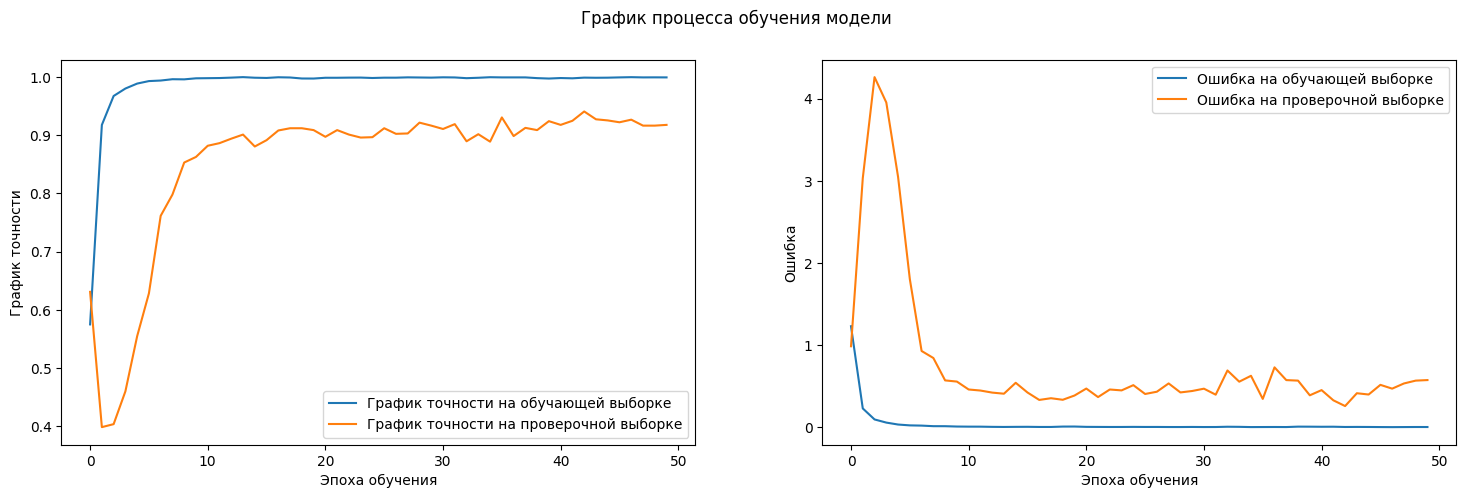

In [ ]:
show_plot(history)

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


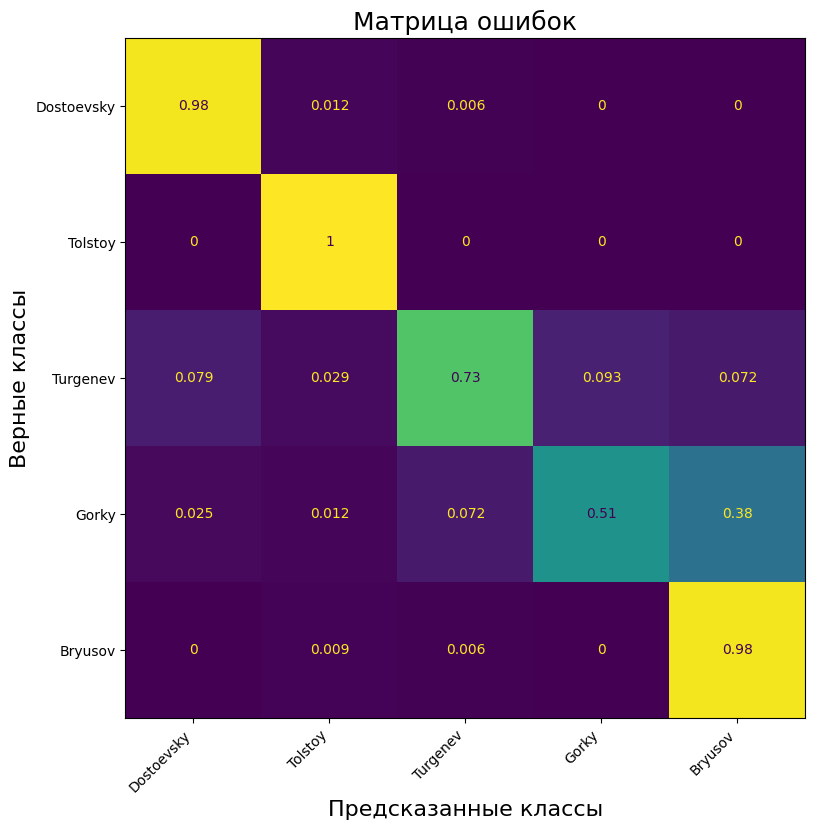


Средняя точность распознавания:  84%


In [ ]:
y_pred = model.predict(x_test) # точность по модели с последней эпохи
show_confusion_matrix(y_test, y_pred, CLASS_LIST)

49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


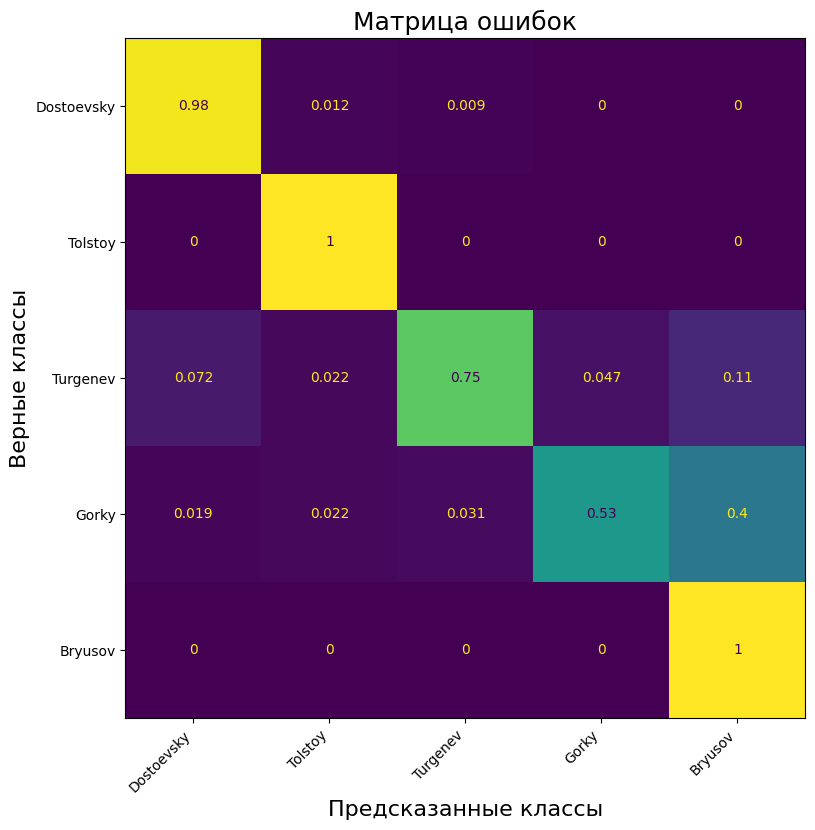


Средняя точность распознавания:  85%


In [ ]:
best_model = keras.models.load_model('best_model_pretrain.keras')
y_pred = best_model.predict(x_test) # точность по модели с лучшей эпохи
show_confusion_matrix(y_test, y_pred, CLASS_LIST)